# NYC 311 Maintenance Priority Modeling

This notebook walks through a maintenance-priority model using public NYC 311/HPD housing service requests. The public data is not a private work-order system, but it is close enough to practice the same analytics pattern: clean the raw requests, engineer features, define a review label, train a model, and inspect results.

## 1. Setup

The notebook imports the same data and modeling utilities used by the command-line scripts.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'scripts'))
sys.path.insert(0, str(ROOT / 'src'))

from download_data import build_training_table, download_public_requests
from maintenance_priority import LogisticPriorityModel, binary_metrics, build_feature_matrix

## 2. Download And Prepare Public Service Requests

The processed table contains public HPD complaint records from NYC 311. The target is a priority-follow-up proxy based on open status, closure time, and complaint category.

In [2]:
processed_path = ROOT / 'data' / 'processed' / 'nyc_311_hpd_priority_training.csv'

if processed_path.exists():
    requests_df = pd.read_csv(processed_path)
else:
    raw_requests = download_public_requests()
    requests_df = build_training_table(raw_requests)
    processed_path.parent.mkdir(parents=True, exist_ok=True)
    requests_df.to_csv(processed_path, index=False)

requests_df.head()

,unique_key,created_month,is_winter,complaint_type,descriptor,has_descriptor,borough,incident_zip,status,location_type,open_data_channel_type,closure_days,priority_followup
0,66755054,11,1,APPLIANCE,REFRIGERATOR,1,MANHATTAN,10029.0,Closed,RESIDENTIAL BUILDING,PHONE,125.635000,1
1,66778902,11,1,GENERAL,COOKING GAS,1,MANHATTAN,10016.0,Closed,RESIDENTIAL BUILDING,PHONE,124.378414,1
2,66809809,11,1,ELECTRIC,OUTLET/SWITCH,1,MANHATTAN,10024.0,Closed,RESIDENTIAL BUILDING,PHONE,120.717581,1
3,67045411,12,1,UNSANITARY CONDITION,MOLD,1,BROOKLYN,11206.0,Closed,RESIDENTIAL BUILDING,PHONE,99.882662,1
4,67175899,12,1,ELECTRIC,NO LIGHTING,1,BRONX,10460.0,Closed,RESIDENTIAL BUILDING,PHONE,89.226597,1


## 3. Summary Measures

I check complaint volumes, class balance, and closure-time behavior before training. This gives me a practical sense of the data quality.

In [3]:
summary = {
    'rows': len(requests_df),
    'complaint_types': requests_df['complaint_type'].nunique(),
    'boroughs': requests_df['borough'].nunique(),
    'priority_rate': requests_df['priority_followup'].mean(),
    'median_closure_days': requests_df['closure_days'].median(),
}

pd.Series(summary).to_frame('value')

,value
rows,50000.000000
complaint_types,13.000000
boroughs,5.000000
priority_rate,0.720780
median_closure_days,6.285428


In [ ]:
requests_df['complaint_type'].value_counts().head(12).to_frame('request_count')

## 4. Data Wrangling And Feature Engineering

The feature matrix one-hot encodes complaint type, borough, and reporting channel. It also keeps simple operational fields such as month, winter flag, and descriptor availability.

In [4]:
features = build_feature_matrix(requests_df)
target = requests_df['priority_followup'].astype(int)

features.head()

,created_month,is_winter,has_descriptor,is_residential_location,complaint_appliance,complaint_door_window,complaint_electric,complaint_flooring_stairs,complaint_general,complaint_heat_hot_water,...,complaint_water_leak,borough_bronx,borough_brooklyn,borough_manhattan,borough_queens,borough_staten_island,channel_mobile,channel_online,channel_phone,channel_unknown
0,11,1,1,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,11,1,1,1,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,11,1,1,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,12,1,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,12,1,1,1,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [5]:
feature_summary = features.agg(['mean', 'std']).T.sort_values('mean', ascending=False)
feature_summary.head(15).round(3)

,mean,std
created_month,4.179,2.832
has_descriptor,1.000,0.000
is_residential_location,1.000,0.000
is_winter,0.602,0.489
channel_online,0.480,0.500
channel_phone,0.457,0.498
borough_bronx,0.354,0.478
complaint_heat_hot_water,0.324,0.468
borough_brooklyn,0.269,0.444
borough_manhattan,0.235,0.424


## 5. Correlation Review

Correlation is a quick screening tool here. I use it to see which engineered fields move with the priority-follow-up proxy.

In [6]:
corr_frame = features.copy()
corr_frame['priority_followup'] = target
target_corr = corr_frame.corr(numeric_only=True)['priority_followup'].sort_values(ascending=False)
target_corr.head(15).round(3)

priority_followup                 1.000
complaint_unsanitary_condition    0.224
channel_phone                     0.157
complaint_plumbing                0.128
complaint_water_leak              0.123
complaint_electric                0.072
complaint_general                 0.046
complaint_appliance               0.039
complaint_door_window             0.034
borough_brooklyn                  0.030
complaint_flooring_stairs         0.024
created_month                     0.022
borough_queens                    0.019
is_winter                         0.008
borough_staten_island            -0.004
Name: priority_followup, dtype: float64

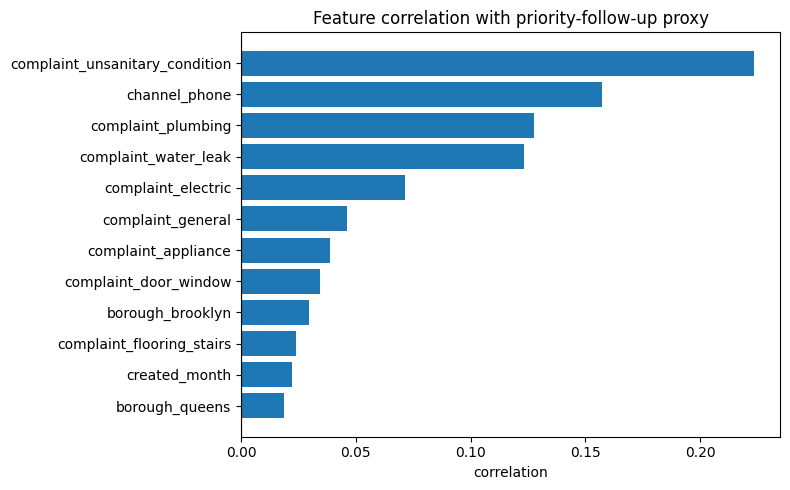

In [7]:
plot_corr = target_corr.drop('priority_followup').head(12).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(plot_corr.index, plot_corr.values)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature correlation with priority-follow-up proxy')
plt.xlabel('correlation')
plt.tight_layout()
plt.show()

## 6. Train/Test Split And Logistic Model

The model is a transparent logistic regression trained from scratch. I use the same deterministic split as the script so results are repeatable.

In [8]:
test_mask = (requests_df.index % 4) == 0

X_train = features.loc[~test_mask].to_numpy()
X_test = features.loc[test_mask].to_numpy()
y_train = target.loc[~test_mask].to_numpy()
y_test = target.loc[test_mask].to_numpy()

model = LogisticPriorityModel()
model.fit(X_train, y_train)

preds = model.predict(X_test)
metrics = binary_metrics(y_test, preds)
metrics

{'accuracy': 0.7666,
 'precision': 0.799,
 'recall': 0.905,
 'f1': 0.8487,
 'tp': 8179,
 'tn': 1404,
 'fp': 2058,
 'fn': 859}

## 7. Model Interpretation

Because the model is linear after scaling, the weights give a straightforward way to inspect what is pushing a request toward or away from priority review.

In [9]:
weights = (
    pd.DataFrame({'feature': features.columns, 'weight': model.weights_})
    .assign(abs_weight=lambda frame: frame['weight'].abs())
    .sort_values('abs_weight', ascending=False)
)

weights[['feature', 'weight']].head(15)

,feature,weight
9,complaint_heat_hot_water,-0.587943
12,complaint_unsanitary_condition,0.513652
13,complaint_water_leak,0.289363
11,complaint_plumbing,0.223339
1,is_winter,0.208111
10,complaint_paint_plaster,-0.144575
6,complaint_electric,0.133435
0,created_month,-0.073638
19,channel_mobile,-0.072292
21,channel_phone,0.061539


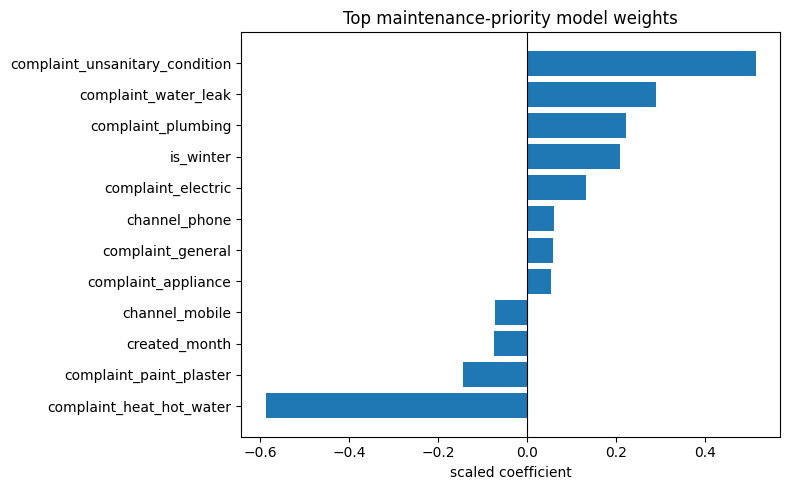

In [10]:
top_weights = weights.head(12).sort_values('weight')

plt.figure(figsize=(8, 5))
plt.barh(top_weights['feature'], top_weights['weight'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top maintenance-priority model weights')
plt.xlabel('scaled coefficient')
plt.tight_layout()
plt.show()

## 8. Prediction Distribution

The probability distribution helps tune the threshold later. A threshold should be selected with operations input, not just by accepting the default `0.50`.

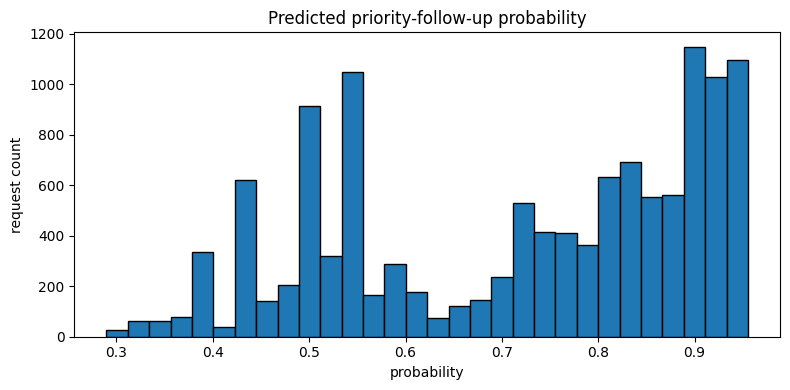

In [11]:
probabilities = model.predict_proba(X_test)

plt.figure(figsize=(8, 4))
plt.hist(probabilities, bins=30, edgecolor='black')
plt.title('Predicted priority-follow-up probability')
plt.xlabel('probability')
plt.ylabel('request count')
plt.tight_layout()
plt.show()

## 9. Save A Model Payload

The command-line training script writes this JSON payload to `artifacts/maintenance_priority_model.json`.

In [12]:
payload = model.to_dict(features.columns, metrics)
payload.keys()

dict_keys(['model_type', 'feature_names', 'weights', 'bias', 'mean', 'scale', 'metrics', 'privacy_note'])